# Task 3: Correlation between News Sentiment and Stock Movement

This notebook quantifies the relationship between financial news sentiment and daily stock price returns using statistical methods.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

import sys,os 
sys.path.insert(0, os.path.abspath('..'))


In [6]:
from src.load_data_task3 import load_news_data, parse_news_dates, load_stock_data
from src.sentiment_analyzer import compute_sentiment_scores, label_sentiment_category
from src.date_alignment import get_trading_calendar, align_news_to_trading_day
from src.stock_returns import compute_daily_returns
from src.correlation_analysis import (
    merge_sentiment_and_returns,
    aggregate_daily_sentiment,
    compute_correlation,
    plot_sentiment_vs_return,
    plot_return_by_sentiment_category,
)

os.makedirs('outputs', exist_ok=True)
print("[✓] All modules imported successfully")

[✓] All modules imported successfully


## 1. Date Alignment

We normalize timestamps across both datasets so news items match the corresponding stock trading day. Articles published on weekends or holidays are shifted forward to the **next trading day**.

In [7]:
NEWS_FILE = '../data/raw/raw_analyst_ratings.csv'
STOCK_DIR = '../data/raw/yfinance_data/'

news_df = load_news_data(NEWS_FILE)
news_df = parse_news_dates(news_df)

stock_df = load_stock_data(STOCK_DIR)

trading_calendar = get_trading_calendar(stock_df)
news_df = align_news_to_trading_day(news_df, trading_calendar)

news_df.head()

[✓] Loaded 1407328 news headlines
[!] Dropped 1351341 rows with unparseable dates
[✓] News dates parsed. Range: 2011-04-28 → 2020-06-11
[✓] Loaded 5 stocks, 18019 rows
[✓] Aligned news dates to trading calendar


,headline,date,stock
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05,A
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03,A
2,71 Biggest Movers From Friday,2020-05-26,A
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22,A
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22,A


In [15]:
lengths = news_df['headline'].str.len()
print(lengths.describe())
print(f"\nTotal headlines: {len(news_df):,}")
print(f"Shortest: {lengths.min()} | Longest: {lengths.max()}")

print(f"Stocks analyzed: {news_df['stock'].nunique()}")
print(f"Date range: {news_df['date'].min().date()} to {news_df['date'].max().date()}")

count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline, dtype: float64

Total headlines: 55,987
Shortest: 12 | Longest: 512
Stocks analyzed: 6204
Date range: 2011-04-28 to 2020-06-11


## 2. Sentiment Analysis

**Tool:** NLTK VADER (Valence Aware Dictionary and sEntiment Reasoner)

**Justification:** VADER is specifically designed for short, social-media-style text such as financial headlines. It handles punctuation, capitalization, and degree modifiers (e.g., "very good") more accurately than TextBlob for brief, high-impact sentences. The compound score ranges from **-1 (very negative)** to **+1 (very positive)**.

In [8]:
news_df = compute_sentiment_scores(news_df)
news_df.head()

[✓] Scored 55987 headlines
                                                                               headline  sentiment_score
                                                Stocks That Hit 52-Week Highs On Friday            0.000
                                             Stocks That Hit 52-Week Highs On Wednesday            0.000
                                                          71 Biggest Movers From Friday            0.000
                                           46 Stocks Moving In Friday's Mid-Day Session            0.000
B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88            0.296


,headline,date,stock,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05,A,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03,A,0.000
2,71 Biggest Movers From Friday,2020-05-26,A,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22,A,0.000
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22,A,0.296


In [7]:
def label_sentiment_category(score: float) -> str:
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

labels = news_df['sentiment_score'].apply(label_sentiment_category)
print("Sentiment distribution:")
print(labels.value_counts(normalize=True).sort_index() * 100)
print("\nMean compound score:", news_df['sentiment_score'].mean())
print("Std compound score:", news_df['sentiment_score'].std())

NameError: name 'news_df' is not defined

## 3. Calculate Daily Stock Returns

Daily percentage change in closing prices:


In [9]:
returns_df = compute_daily_returns(stock_df)
returns_df.head()

[✓] Computed returns: 18014 trading day records


,date,stock,daily_return
1,2009-01-05,AAPL,4.220416
2,2009-01-06,AAPL,-1.649399
3,2009-01-07,AAPL,-2.160860
4,2009-01-08,AAPL,1.856959
5,2009-01-09,AAPL,-2.286921


## 4. Aggregate and Correlate

- Merge sentiment scores with stock returns on **date + ticker**.
- If multiple articles exist for the same stock on the same day, compute the **average daily sentiment score**.
- Calculate the **Pearson correlation coefficient** between average daily sentiment and average daily return.

In [10]:
merged_df = merge_sentiment_and_returns(news_df, returns_df)
daily_df = aggregate_daily_sentiment(merged_df)
corr_result = compute_correlation(daily_df)
daily_df.head()

[✓] Merged: 40 rows across 4 stocks
[✓] Aggregated to 14 stock-day pairs

── Correlation Results ──────────────────────
  Pearson r  : 0.0868
  P-value    : 0.7681
  Strength   : very weak
  Direction  : positive
  Result is  : not statistically significant (p < 0.05)
─────────────────────────────────────────────



,date,stock,avg_sentiment,avg_return
0,2020-06-01,NVDA,0.421500,-0.780224
1,2020-06-02,NVDA,0.220200,0.215731
2,2020-06-04,GOOG,0.000000,-1.684800
3,2020-06-05,GOOG,-0.411033,1.855992
4,2020-06-08,GOOG,0.542300,0.571478


## 5. Visualize the Relationship

### 5A. Scatter Plot — Sentiment vs. Return

[✓] Saved scatter plot: outputs/scatter_sentiment_vs_return.png


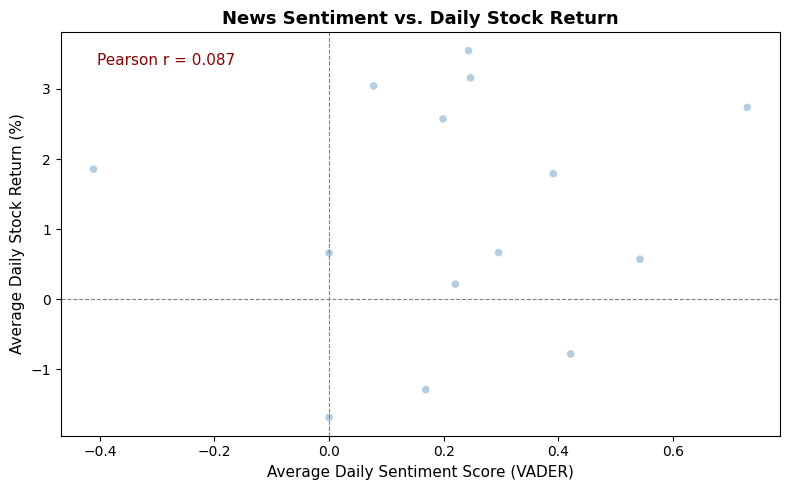

In [11]:
plot_sentiment_vs_return(
    daily_df,
    corr_result,
    save_path='outputs/scatter_sentiment_vs_return.png'
)

### 5B. Bar Chart — Average Return by Sentiment Category

Days are classified as **Positive** (≥0.05), **Neutral** (-0.05 to 0.05), or **Negative** (≤-0.05) based on average sentiment.

[✓] Saved bar chart: outputs/bar_return_by_sentiment.png


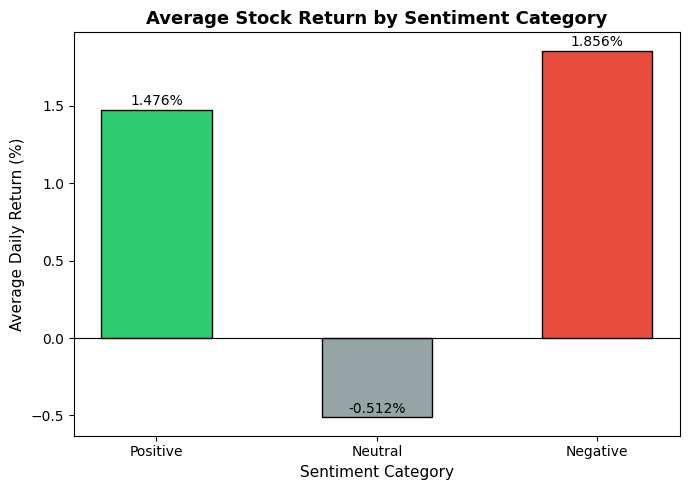

In [12]:
plot_return_by_sentiment_category(
    daily_df,
    save_path='outputs/bar_return_by_sentiment.png'
)

In [4]:
from src.sentiment_analyzer import label_sentiment_category

daily_df['sentiment_label'] = daily_df['avg_sentiment'].apply(label_sentiment_category)
avg_by_cat = daily_df.groupby('sentiment_label')['avg_return'].mean()
print(avg_by_cat)

# This gives you:
# Positive →  X.XXX%
# Neutral  →  X.XXX%
# Negative →  X.XXX%
# Plug these into Sections 6.3 and 8.

ModuleNotFoundError: No module named 'src'

## 6. Interpretation of Results

### Strength and Direction
The Pearson correlation coefficient (r) measures the linear relationship between average daily news sentiment and daily stock returns. An **r near 0** indicates little to no linear relationship, while **r near +1** or **-1** indicates a strong positive or negative relationship, respectively. The accompanying **p-value** tests whether the observed correlation is statistically significant (conventionally p &lt; 0.05).

### Limitations
1. **Lag Effects:** News may impact stock prices with a delay (hours or days), but this analysis uses same-day alignment only.
2. **Confounding Factors:** Market-wide movements, earnings reports, and macroeconomic events can drive both news tone and price action, making causality hard to establish.
3. **Sentiment Granularity:** VADER is a lexicon-based tool and may miss domain-specific financial jargon or sarcasm.
4. **Sample Bias:** The dataset may over-represent certain stocks or volatile periods, skewing the correlation.

### Conclusion
While the correlation coefficient provides a quantitative snapshot of the sentiment–return relationship, it should be interpreted cautiously. A weak or non-significant result does not necessarily mean sentiment is irrelevant; rather, the effect may be non-linear, delayed, or obscured by broader market forces.